In [49]:

import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [50]:

# Set random seeds for reproducibility
torch.manual_seed(42)

In [51]:

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [52]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [53]:

df.shape

(6000, 785)

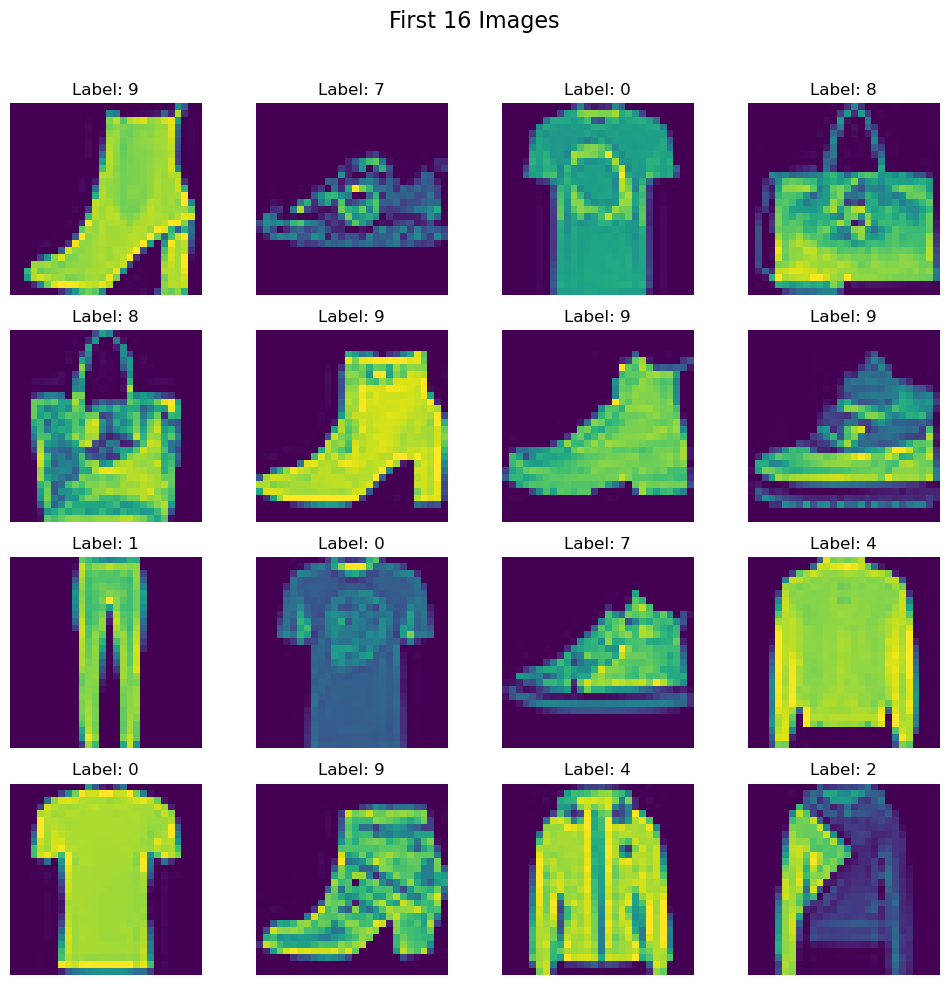

In [54]:

# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

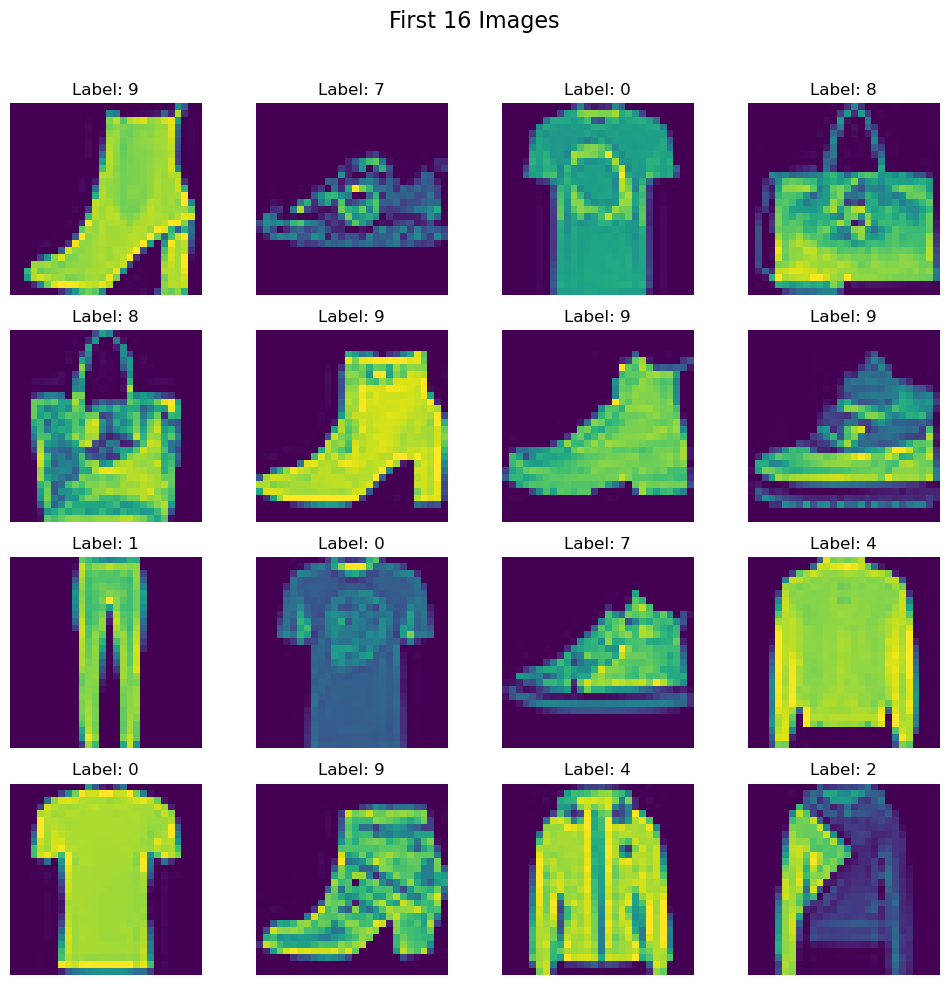

In [55]:

# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [56]:
# Extract features and labels from the dataframe
X = df.iloc[:, 1:].to_numpy(dtype='float32')
y = df.iloc[:, 0].to_numpy(dtype='int64')

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:

X_train = X_train/255.0
X_test = X_test/255.0
     

In [59]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [60]:
train_dataset = CustomDataset(X_train, y_train)

In [61]:

test_dataset = CustomDataset(X_test, y_test)

In [62]:

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [63]:
len(train_loader)

150

In [64]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(

            nn.Linear(num_features, 128),

            nn.BatchNorm1d(128),


            nn.ReLU(),

            nn.Linear(128, 64),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [65]:
learning_rate = 0.01
epochs = 100

In [66]:


model = MyNN(X_train.shape[1])

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

In [67]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


c:\Users\User\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch: 1 , Loss: 0.8001452940702438
Epoch: 2 , Loss: 0.5341661135355632
Epoch: 3 , Loss: 0.45448968519767124
Epoch: 4 , Loss: 0.3997308307886124
Epoch: 5 , Loss: 0.3467998937269052
Epoch: 6 , Loss: 0.3326572886109352
Epoch: 7 , Loss: 0.3069241865972678
Epoch: 8 , Loss: 0.2797084340453148
Epoch: 9 , Loss: 0.23704689582188923
Epoch: 10 , Loss: 0.23406294927001
Epoch: 11 , Loss: 0.20869185974200566
Epoch: 12 , Loss: 0.19418414597709974
Epoch: 13 , Loss: 0.1889633994922042
Epoch: 14 , Loss: 0.17255532736579576
Epoch: 15 , Loss: 0.16981294446935255
Epoch: 16 , Loss: 0.15226183159897724
Epoch: 17 , Loss: 0.13709614520271618
Epoch: 18 , Loss: 0.14145930742224058
Epoch: 19 , Loss: 0.12685155543188253
Epoch: 20 , Loss: 0.11789511122430364
Epoch: 21 , Loss: 0.12382125502452254
Epoch: 22 , Loss: 0.10136050820350646
Epoch: 23 , Loss: 0.0903118233072261
Epoch: 24 , Loss: 0.10389271633078655
Epoch: 25 , Loss: 0.10042396908005079
Epoch: 26 , Loss: 0.08599629953503608
Epoch: 27 , Loss: 0.0826254144792

In [68]:

model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [69]:

# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8383333333333334
